In [18]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from classification.features import LABEL_TO_CLASS, extract_features_matrix, load_train_test

RANDOM_STATE = 42
ROOT = Path.cwd()
PREPROCESSED_DIR = ROOT / "apples_tomatoes_preprocessed"
OUTPUT_DIR = ROOT / "classification" / "output_svm"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")

## 1) Wczytanie danych i ekstrakcja cech

In [19]:
train_df, test_df = load_train_test(PREPROCESSED_DIR)

print(f"Train images: {len(train_df)}")
print(train_df["class_name"].value_counts().sort_index())
print(f"\nTest images:  {len(test_df)}")
print(test_df["class_name"].value_counts().sort_index())

Train images: 294
class_name
apples      164
tomatoes    130
Name: count, dtype: int64

Test images:  97
class_name
apples      54
tomatoes    43
Name: count, dtype: int64


In [20]:
all_df = pd.concat([train_df, test_df], ignore_index=True)

cache_path = ROOT / "classification" / "output" / "features_cache.npz"

X_all, feature_names = extract_features_matrix(
    all_df["path"].tolist(),
    cache_path=cache_path,
    use_cache=True,
)

n_train = len(train_df)
X_train = X_all[:n_train]
X_test  = X_all[n_train:]
y_train = train_df["label"].to_numpy(dtype=np.int32)
y_test  = test_df["label"].to_numpy(dtype=np.int32)

print(f"Feature matrix train: {X_train.shape}")
print(f"Feature matrix test:  {X_test.shape}")
print(f"Liczba cech:          {len(feature_names)}")

Feature matrix train: (294, 31)
Feature matrix test:  (97, 31)
Liczba cech:          31


## 2) Podział train/val i filtracja korelacji

In [21]:
def get_uncorrelated_indices(X: np.ndarray, threshold: float = 0.95) -> list[int]:
    corr = pd.DataFrame(X).corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [int(col) for col in upper.columns if (upper[col] > threshold).any()]
    return [i for i in range(X.shape[1]) if i not in to_drop]


CORR_THRESHOLD = 0.95

indices = np.arange(len(y_train))
X_fit, X_val, y_fit, y_val, idx_fit, idx_val = train_test_split(
    X_train, y_train, indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

keep_idx_fit = get_uncorrelated_indices(X_fit, threshold=CORR_THRESHOLD)
X_fit_corr = X_fit[:, keep_idx_fit]
X_val_corr = X_val[:, keep_idx_fit]
feature_names_corr = [feature_names[i] for i in keep_idx_fit]

print(f"Cech po filtracji korelacji: {len(feature_names)} → {len(feature_names_corr)}")
print(f"Train-fit: {X_fit_corr.shape[0]} | Val: {X_val_corr.shape[0]}")

Cech po filtracji korelacji: 31 → 21
Train-fit: 235 | Val: 59


## 3) Porównanie kerneli SVM

In [22]:
kernel_results = []

for kernel in ("linear", "rbf", "poly", "sigmoid"):
    pipe = Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=16)),
        ("clf",      SVC(kernel=kernel, probability=True,
                         class_weight="balanced", random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_fit_corr, y_fit)
    y_prob = pipe.predict_proba(X_val_corr)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    kernel_results.append({
        "kernel":   kernel,
        "accuracy": round(accuracy_score(y_val, y_pred), 4),
        "f1_macro": round(f1_score(y_val, y_pred, average="macro"), 4),
        "roc_auc":  round(roc_auc_score(y_val, y_prob), 4),
    })

kernel_df = pd.DataFrame(kernel_results).sort_values("f1_macro", ascending=False)
display(kernel_df)

,kernel,accuracy,f1_macro,roc_auc
0,linear,0.7797,0.7755,0.7179
2,poly,0.7458,0.7410,0.7634
1,rbf,0.7119,0.7105,0.8322
3,sigmoid,0.6610,0.6586,0.6597


## 4) GridSearchCV – tuning hiperparametrów

In [23]:
k_candidates = [8, 12, 16, 20, 25]
k_values = sorted({k for k in k_candidates if k <= X_fit_corr.shape[1]})

param_grid = {
    "selector__k":    k_values,
    "clf__C":         [0.1, 1, 10, 50, 100],
    "clf__gamma":     ["scale", "auto", 0.01, 0.001],
    "clf__kernel":    ["rbf", "poly"],
    "clf__degree":    [2, 3],
    "clf__class_weight": ["balanced", {0: 1, 1: 2.0}],
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif)),
        ("clf",      SVC(probability=True, random_state=RANDOM_STATE)),
    ]),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid.fit(X_fit_corr, y_fit)

print("Best CV score (f1_macro):", round(grid.best_score_, 4))
print("Best params:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

Fitting 10 folds for each of 640 candidates, totalling 6400 fits
Best CV score (f1_macro): 0.7421
Best params:
  clf__C: 10
  clf__class_weight: {0: 1, 1: 2.0}
  clf__degree: 2
  clf__gamma: scale
  clf__kernel: rbf
  selector__k: 16


## 5) Optymalizacja progu decyzyjnego (walidacja)

In [24]:
best_model = grid.best_estimator_

y_val_prob = best_model.predict_proba(X_val_corr)[:, 1]

thresholds = np.linspace(0.30, 0.70, 81)
best_threshold, best_f1_thr = 0.5, -1.0

for thr in thresholds:
    f1_thr = f1_score(y_val, (y_val_prob >= thr).astype(int), average="macro")
    if f1_thr > best_f1_thr:
        best_f1_thr = f1_thr
        best_threshold = float(thr)

val_comparison = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_val, (y_val_prob >= 0.50).astype(int)),
            accuracy_score(y_val, (y_val_prob >= best_threshold).astype(int)),
        ],
        "f1_macro": [
            f1_score(y_val, (y_val_prob >= 0.50).astype(int), average="macro"),
            f1_score(y_val, (y_val_prob >= best_threshold).astype(int), average="macro"),
        ],
        "roc_auc":  [roc_auc_score(y_val, y_val_prob)] * 2,
    },
    index=["default_thr_0.50", f"tuned_thr_{best_threshold:.2f}"],
)

print(f"Optymalny próg (walidacja): {best_threshold:.3f}")
display(val_comparison.round(4))

Optymalny próg (walidacja): 0.430


,accuracy,f1_macro,roc_auc
default_thr_0.50,0.7797,0.7786,0.8205
tuned_thr_0.43,0.7797,0.7786,0.8205


## 6) Retrain na pełnym zbiorze treningowym i ewaluacja testowa

In [25]:
keep_idx_train = get_uncorrelated_indices(X_train, threshold=CORR_THRESHOLD)
feature_names_corr_train = [feature_names[i] for i in keep_idx_train]
X_train_corr = X_train[:, keep_idx_train]
X_test_corr  = X_test[:, keep_idx_train]

best_k = min(grid.best_params_["selector__k"], X_train_corr.shape[1])

final_model = Pipeline([
    ("scaler",   StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=best_k)),
    ("clf",      SVC(
        probability=True,
        random_state=RANDOM_STATE,
        kernel=grid.best_params_["clf__kernel"],
        C=grid.best_params_["clf__C"],
        gamma=grid.best_params_["clf__gamma"],
        degree=grid.best_params_["clf__degree"],
        class_weight=grid.best_params_["clf__class_weight"],
    )),
])

final_model.fit(X_train_corr, y_train)
print("Final SVM model retrained on full train split.")
print(f"Cech po filtracji korelacji: {len(feature_names_corr_train)}")
print(f"SelectKBest k: {best_k}")

Final SVM model retrained on full train split.
Cech po filtracji korelacji: 21
SelectKBest k: 16


In [26]:
y_test_prob  = final_model.predict_proba(X_test_corr)[:, 1]
y_test_pred  = (y_test_prob >= best_threshold).astype(int)

summary = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_test, (y_test_prob >= 0.50).astype(int)),
            accuracy_score(y_test, y_test_pred),
        ],
        "f1_macro": [
            f1_score(y_test, (y_test_prob >= 0.50).astype(int), average="macro"),
            f1_score(y_test, y_test_pred, average="macro"),
        ],
        "roc_auc": [roc_auc_score(y_test, y_test_prob)] * 2,
    },
    index=["default_thr_0.50", f"tuned_thr_{best_threshold:.2f}"],
)

print("Metryki testowe (default vs tuned threshold):")
display(summary.round(4))

Metryki testowe (default vs tuned threshold):


,accuracy,f1_macro,roc_auc
default_thr_0.50,0.7526,0.7481,0.7446
tuned_thr_0.43,0.6907,0.6899,0.7446


## 7) Szczegółowe metryki testowe

In [27]:
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average=None, labels=[0, 1]
)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="macro"
)

metrics_table = pd.DataFrame(
    {
        "class":     [LABEL_TO_CLASS[0], LABEL_TO_CLASS[1], "macro"],
        "precision": [prec[0], prec[1], macro_p],
        "recall":    [rec[0],  rec[1],  macro_r],
        "f1":        [f1[0],   f1[1],   macro_f1],
    }
)
display(metrics_table.round(4))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred,
                             target_names=[LABEL_TO_CLASS[0], LABEL_TO_CLASS[1]]))

,class,precision,recall,f1
0,apples,0.7500,0.6667,0.7059
1,tomatoes,0.6327,0.7209,0.6739
2,macro,0.6913,0.6938,0.6899



Classification report:
              precision    recall  f1-score   support

      apples       0.75      0.67      0.71        54
    tomatoes       0.63      0.72      0.67        43

    accuracy                           0.69        97
   macro avg       0.69      0.69      0.69        97
weighted avg       0.70      0.69      0.69        97



## 8) Wizualizacje: Confusion Matrix i ROC

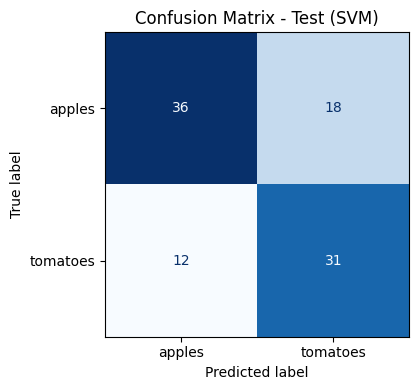

In [28]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["apples", "tomatoes"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Confusion Matrix - Test (SVM)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_svm.png", dpi=150)
plt.show()

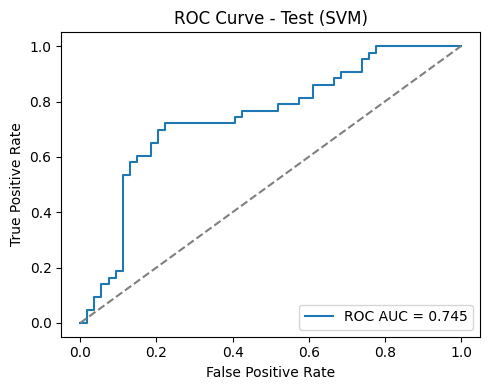

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Test (SVM)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_svm.png", dpi=150)
plt.show()

## 9) Wizualizacja PCA 2D wybranych cech (SVM decision boundary)

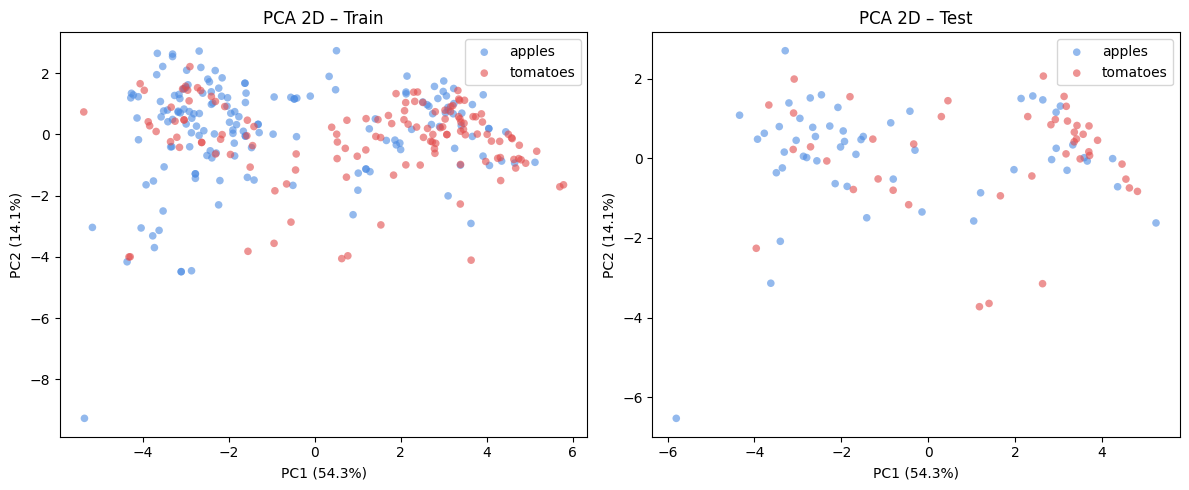

PCA wyjaśniona wariancja: PC1=54.3%, PC2=14.1%


In [30]:
scaler   = final_model.named_steps["scaler"]
selector = final_model.named_steps["selector"]

X_train_scaled   = scaler.transform(X_train_corr)
X_train_selected = selector.transform(X_train_scaled)
X_test_scaled    = scaler.transform(X_test_corr)
X_test_selected  = selector.transform(X_test_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_selected)
X_test_2d  = pca.transform(X_test_selected)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ["Train", "Test"]
datasets = [(X_train_2d, y_train), (X_test_2d, y_test)]
colors = {0: "#4C8BE2", 1: "#E24C4C"}
labels_map = {0: "apples", 1: "tomatoes"}

for ax, title, (X_2d, y) in zip(axes, titles, datasets):
    for cls in [0, 1]:
        mask = y == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[cls], label=labels_map[cls],
                   alpha=0.6, s=30, edgecolors="none")
    ax.set_title(f"PCA 2D – {title}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_2d_svm.png", dpi=150)
plt.show()

print(f"PCA wyjaśniona wariancja: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

## 10) Błędne klasyfikacje

Błędnie sklasyfikowanych: 30 / 97


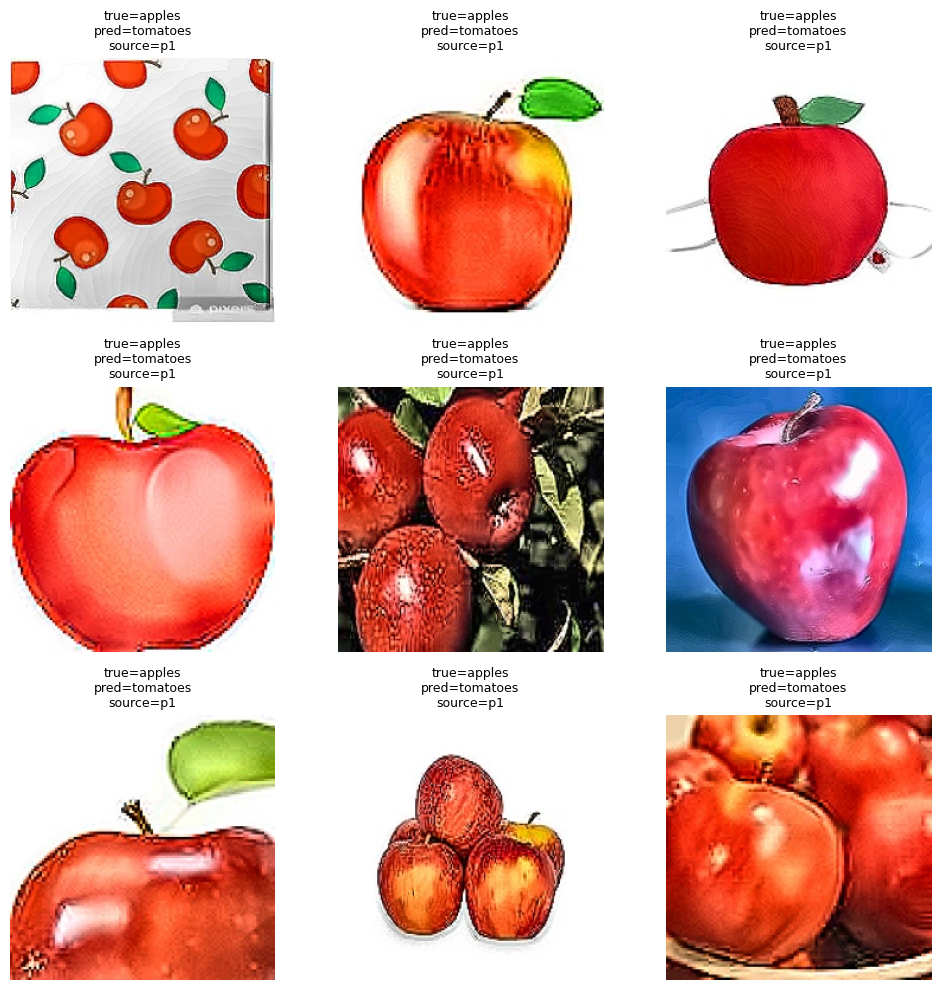

In [31]:
error_idx = np.where(y_test_pred != y_test)[0]
print(f"Błędnie sklasyfikowanych: {len(error_idx)} / {len(y_test)}")

show_n = min(9, len(error_idx))
if show_n == 0:
    print("Brak błędnych klasyfikacji.")
else:
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()
    for ax_idx, sample_idx in enumerate(error_idx[:show_n]):
        ax = axes[ax_idx]
        image = cv2.imread(test_df.iloc[sample_idx]["path"])
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = LABEL_TO_CLASS[int(y_test[sample_idx])]
        pred_label = LABEL_TO_CLASS[int(y_test_pred[sample_idx])]
        source = test_df.iloc[sample_idx]["source"]

        ax.imshow(image_rgb)
        ax.set_title(f"true={true_label}\npred={pred_label}\nsource={source}", fontsize=9)
        ax.axis("off")

    for ax in axes[show_n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "misclassified_svm.png", dpi=150)
    plt.show()

## 11) Metryki per źródło (p1/p2/p3)

In [32]:
source_results = []
for source in sorted(test_df["source"].unique()):
    idx = np.where((test_df["source"] == source).to_numpy())[0]
    y_true_src = y_test[idx]
    y_pred_src = y_test_pred[idx]
    source_results.append({
        "source":   source,
        "count":    int(len(idx)),
        "accuracy": round(float(accuracy_score(y_true_src, y_pred_src)), 4),
        "f1_macro": round(float(f1_score(y_true_src, y_pred_src, average="macro")), 4),
    })

display(pd.DataFrame(source_results).sort_values("source"))

,source,count,accuracy,f1_macro
0,p1,47,0.7447,0.7350
1,p2,24,0.5417,0.5409
2,p3,26,0.7308,0.7271
